# Карта расхождений Qwen

Teacher: Qwen3.5-2B-Base. Student: Qwen3.5-0.8B-Base. Представление: BGE CLS.

Colab → GPU T4 → выполнить по порядку. Notebook сам загружает данные и считает карту; входной архив не нужен.

θ — доля текстов с JSD≤0,05 по оценке GP. Чем меньше θ, тем сильнее расходятся модели в домене. Это сравнение распределений, а не accuracy ответов.


In [1]:
# QWEN_CELL: packages
%pip -q install numpy==2.1.3 transformers==5.16.1 huggingface_hub==1.29.0 datasets==4.8.5 scikit-learn==1.6.1 umap-learn==0.5.12 scipy==1.16.3 pandas matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 795.8/795.8 kB 43.3 MB/s eta 0:00:00


## Конфиг

Домены, модели, размеры пула, кластерный старт, GP и отбор задаются здесь. По умолчанию192 измерения для карты и отдельная проверка на240 текстах.


In [2]:
# QWEN_CELL: config
config = {'teacher': {'id': 'Qwen/Qwen3.5-2B-Base', 'revision': 'b1485b2fa6dfa1287294f269f5fb618e03d52d7c'},
 'student': {'id': 'Qwen/Qwen3.5-0.8B-Base',
             'revision': 'dc7cdfe2ee4154fa7e30f5b51ca41bfa40174e68'},
 'encoder': {'id': 'BAAI/bge-base-en-v1.5', 'revision': 'a5beb1e3e68b9ab74eb54cfd186867f64f240e1a'},
 'pool_kind': 'mmlu',
 'domains': ['high_school_biology',
             'high_school_physics',
             'high_school_statistics',
             'logical_fallacies',
             'professional_medicine',
             'moral_disputes'],
 'domain_sources': [],
 'samples_per_domain': 100,
 'mmlu_revision': 'c30699e8356da336a370243923dbaf21066bb9fe',
 'seed': 100,
 'data_seed': 20261003,
 'qwen_max_length': 256,
 'encoder_max_length': 256,
 'shuffle_buffer_size': 1000,
 'validation_per_domain': 20,
 'holdout_per_domain': 20,
 'initial_strategy': 'cluster',
 'n_clusters': 4,
 'points_per_cluster': 5,
 'initial_per_domain': 4,
 'kernel': 'gp_matern32',
 'target_transform': 'raw',
 'acquisition': 'random',
 'budget': 192,
 'batch_size': 12,
 'epsilon': 0.05,
 'posterior_draws': 256,
 'top_per_domain': 10,
 'search': {'enabled': False, 'acquisition': 'ucb', 'kappa': 5.0, 'budget': 192},
 'compare_policies': False,
 'comparison_budget': 192,
 'kappa_values': [2.0, 5.0, 10.0],
 'validate': True,
 'umap_neighbors': 15,
 'umap_min_dist': 0.1,
 'cache_dir': '/content/qwen_gp_demo_20261007',
 'archive_path': '/content/qwen_gp_demo_results.zip',
 'encoder_pooling': 'cls',
 'diagnostic_hybrid_map': False,
 'raw_prefix_alignment': 'joint_raw_v1'}


In [3]:
# QWEN_CELL: environment
NOTEBOOK_VERSION='qwen_pool_map_v4_joint_raw_candidate'
MAP_QUERY_SCOPE='full_canonical_visible_pool'
NATURAL_DATA_DEFAULTS={'natural_sources': {'fineweb_edu': {'dataset': 'HuggingFaceFW/fineweb-edu', 'config': 'sample-10BT', 'revision': 'b889e174ec04ddb4ddeab6555a3b6fb5f3023a25'}, 'finemath_4plus': {'dataset': 'HuggingFaceTB/finemath', 'config': 'finemath-4plus', 'revision': 'a7dd0df51a9178c8a86c29fcd797c2be9b77379c'}}, 'natural_min_tokens': 128, 'natural_population': 1200, 'natural_per_fold': 300, 'shuffle_buffer': 20000, 'region_chars': 30000, 'scan_limit': 25000}
import base64, gc, hashlib, inspect, io, json, math, re, sys, time, warnings, zipfile, copy
from collections import Counter
from pathlib import Path
from types import SimpleNamespace
from sklearn.cluster import KMeans
import numpy as np
import torch, transformers, huggingface_hub
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import json
import math
from pathlib import Path
import time
import warnings
import numpy as np
from scipy.special import ndtr
from scipy.stats import spearmanr
from sklearn.base import clone
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, RBF, WhiteKernel
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from threadpoolctl import threadpool_limits
if (transformers.__version__, huggingface_hub.__version__) != ('5.16.1', '1.29.0'):
    raise RuntimeError('После установки библиотек перезапустите сессию Colab и выполните ячейки заново.')
if not torch.cuda.is_available():
    raise RuntimeError('Выберите GPU T4 в настройках Colab.')
for old_runtime in [globals().get('runtime'), globals().get('c')]:
    if old_runtime is not None and hasattr(old_runtime, 'MODELS'):
        old_runtime.MODELS.clear()
gc.collect(); torch.cuda.empty_cache()
STARTED = time.perf_counter()
PROTOCOL = dict(version=NOTEBOOK_VERSION, models={r:config[r] for r in ['teacher','student','encoder']},
    data_seed=config['data_seed'], mmlu_revision=config['mmlu_revision'],
    qwen_max_length=config['qwen_max_length'], encoder_max_length=config['encoder_max_length'],
    encoder_pooling=config.get('encoder_pooling','cls'), raw_prefix_alignment='joint_raw_v1', near_duplicate_cosine=.92,
    target_definition='Full-vocabulary JSD, natural log, all valid positions including last')
if config['pool_kind']=='natural' and not config['domain_sources']:
    PROTOCOL.update(NATURAL_DATA_DEFAULTS)
    PROTOCOL['natural_per_fold']=config['samples_per_domain']
runtime=SimpleNamespace(ROOT=Path(config['cache_dir']),CFG=copy.deepcopy(PROTOCOL),
    MODELS={},TOKENIZERS={},MODEL_SPECS={},TOKENIZER_SPECS={})
runtime.ROOT.mkdir(parents=True,exist_ok=True)
(runtime.ROOT/'notebook_config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
print('GPU:',torch.cuda.get_device_name(0),'| свободно GiB:',round(torch.cuda.mem_get_info()[0]/2**30,2))


GPU: Tesla T4 | свободно GiB: 14.46


## Данные

MMLU загружается стримингом. Для своих источников заполните domain_sources; в них задаются domain, path, name, split и text_field. Ответы MMLU в JSD не используются.


In [4]:
# QWEN_CELL: data_helpers
MEASUREMENT_DATA_FIELDS = ('version', 'models', 'data_seed', 'mmlu_revision', 'mmlu_domains', 'natural_sources', 'qwen_max_length', 'encoder_max_length', 'encoder_pooling', 'natural_min_tokens', 'natural_population', 'natural_per_fold', 'shuffle_buffer', 'region_chars', 'scan_limit', 'near_duplicate_cosine', 'target_definition', 'raw_prefix_alignment', 'computation_protocol')

def clean_protocol(protocol):
    """Keep measurement and data settings; branch settings have their own export."""
    return {key: copy.deepcopy(protocol[key]) for key in MEASUREMENT_DATA_FIELDS if key in protocol}

def fingerprint(value):
    return hashlib.sha256(json.dumps(value, ensure_ascii=False, sort_keys=True, separators=(',', ':')).encode()).hexdigest()

def raw_text_sha256(text):
    return hashlib.sha256(text.encode('utf-8')).hexdigest()

def computation_protocol():
    import importlib.metadata
    import sys
    versions = {}
    for package, module in [('transformers', 'transformers'), ('tokenizers', 'tokenizers'), ('torch', 'torch'), ('numpy', 'numpy')]:
        version = getattr(sys.modules.get(module), '__version__', None)
        if version is None:
            try:
                version = importlib.metadata.version(package)
            except importlib.metadata.PackageNotFoundError:
                version = 'not-installed'
        versions[package] = str(version)
    return dict(schema='exact_input_forward_v2', versions=versions, qwen_dtype='float16', encoder_dtype='float32', attention='sdpa', jsd_dtype='float32', document_reduction='numpy_float32_mean', tokenizer_special_tokens=False, tokenizer_truncation_side='right')

def resolve_model_spec(value):
    spec = dict(id=str(value), revision='main') if isinstance(value, (str, Path)) else copy.deepcopy(value)
    local = Path(spec['id'])
    if local.is_dir():
        local = local.resolve()
        files = sorted((p for p in local.rglob('*') if p.is_file() and p.suffix in {'.safetensors', '.bin', '.json', '.model', '.txt', '.tiktoken'} and (not p.name.startswith(('optimizer', 'scheduler', 'rng_state')))))
        digest = hashlib.sha256()
        for file in files:
            digest.update(file.relative_to(local).as_posix().encode('utf-8') + b'\x00')
            with file.open('rb') as handle:
                for chunk in iter(lambda: handle.read(1024 * 1024), b''):
                    digest.update(chunk)
            digest.update(b'\x00')
        if not files:
            raise ValueError('Local checkpoint contains no model/tokenizer artifacts')
        spec.update(id=str(local), revision='local-sha256:' + digest.hexdigest())
    elif spec.get('revision', 'main') == 'main':
        from huggingface_hub import HfApi
        spec['revision'] = HfApi().model_info(spec['id']).sha
    return spec

def measurement_identity(row):
    return fingerprint(dict(schema='pair_jsd_exact_input_v2', sample_id=row['sample_id'], raw_text_sha256=raw_text_sha256(row['text']), models={role: runtime.CFG['models'][role] for role in ['student', 'teacher']}, max_length=runtime.CFG['qwen_max_length'], positions='all_valid_including_last', metric='full_vocabulary_js_natural_log_fp32_v1', alignment=runtime.CFG.get('raw_prefix_alignment', 'none'), computation=runtime.CFG.get('computation_protocol', computation_protocol())))

def save_json(name, value):
    path = runtime.ROOT / name
    path.parent.mkdir(parents=True, exist_ok=True)
    temp = path.with_suffix(path.suffix + '.tmp')
    temp.write_text(json.dumps(value, ensure_ascii=False, indent=2))
    temp.replace(path)
    return path

def load_rows(name):
    return [json.loads(line) for line in (runtime.ROOT / name).read_text().splitlines() if line.strip()]

def save_rows(name, rows):
    path = runtime.ROOT / name
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(''.join((json.dumps(row, ensure_ascii=False) + '\n' for row in rows)))
    return path

def tokenizer(role):
    from transformers import AutoTokenizer
    spec = runtime.CFG['models'][role]
    if role not in runtime.TOKENIZERS or runtime.TOKENIZER_SPECS.get(role) != spec:
        runtime.TOKENIZERS[role] = AutoTokenizer.from_pretrained(spec['id'], revision=spec['revision'])
        runtime.TOKENIZER_SPECS[role] = dict(spec)
    return runtime.TOKENIZERS[role]

def load_model(role):
    import torch
    from transformers import AutoModel, AutoModelForCausalLM
    spec = runtime.CFG['models'][role]
    if role not in runtime.MODELS or runtime.MODEL_SPECS.get(role) != spec:
        factory = AutoModel if role == 'encoder' else AutoModelForCausalLM
        runtime.MODELS[role] = factory.from_pretrained(spec['id'], revision=spec['revision'], dtype=torch.float32 if role == 'encoder' else torch.float16, attn_implementation='sdpa').to('cuda').eval()
        runtime.MODEL_SPECS[role] = dict(spec)
    return runtime.MODELS[role]

def clean_reason(text):
    if '�' in text:
        return 'replacement_character'
    if re.search('[\\x00-\\x08\\x0b\\x0c\\x0e-\\x1f]', text):
        return 'control_character'
    if len(re.findall('(?i)\\bread more\\b', text)) > 3:
        return 'repeated_read_more'
    lines = [line.strip() for line in text.splitlines() if line.strip()]
    if len(lines) >= 12 and sum((bool(re.fullmatch('[\\d\\s.,%+\\-=/()]+', line)) for line in lines)) / len(lines) > 0.6:
        return 'numeric_lines'
    if len(lines) >= 20 and sum((len(line) < 15 for line in lines)) / len(lines) > 0.7:
        return 'short_lines'
    if len(lines) >= 20 and max(Counter(lines).values()) / len(lines) > 0.3:
        return 'repeated_lines'
    return None

def natural_window(text, key):
    tok = tokenizer('encoder')
    ids = tok(text, add_special_tokens=False, return_offsets_mapping=True, verbose=False)
    offsets = ids['offset_mapping']
    if len(offsets) < runtime.CFG['natural_min_tokens']:
        return None
    limit = runtime.CFG['encoder_max_length'] - 2
    start_token = int(fingerprint(['window', key]), 16) % (max(len(offsets) - limit, 0) + 1)
    end_token = min(start_token + limit, len(offsets))
    lo, hi = (offsets[start_token][0], offsets[end_token - 1][1])
    boundaries = [0] + [m.end() for m in re.finditer('(?<=[.!?])\\s+|\\n{2,}', text)] + [len(text)]
    start_candidates = [p for p in boundaries if lo <= p <= lo + 160 and p < hi]
    end_candidates = [p for p in boundaries if hi - 160 <= p <= hi and p > lo]
    trim_lo = min(start_candidates) if start_candidates else lo
    trim_hi = max(end_candidates) if end_candidates else hi
    if trim_hi > trim_lo and len(tok(text[trim_lo:trim_hi], add_special_tokens=False)['input_ids']) >= runtime.CFG['natural_min_tokens']:
        lo, hi = (trim_lo, trim_hi)
    window = text[lo:hi].strip()
    count = len(tok(window, add_special_tokens=False)['input_ids'])
    if count < runtime.CFG['natural_min_tokens']:
        return None
    return (window, lo, hi, count)

def controlled(samples_per_domain=100):
    from datasets import load_dataset
    rows = []
    for domain in runtime.CFG['mmlu_domains']:
        ds = load_dataset('cais/mmlu', domain, revision=runtime.CFG['mmlu_revision'], split='test', streaming=True)
        candidates = []
        for index, item in enumerate(ds):
            text = '\n'.join([item['question'].strip()] + [f'{chr(65 + j)}. {str(choice).strip()}' for j, choice in enumerate(item['choices'])] + ['Answer:'])
            candidates.append({'sample_id': fingerprint(['mmlu', runtime.CFG['mmlu_revision'], domain, index]), 'domain': domain, 'source': 'cais/mmlu', 'revision': runtime.CFG['mmlu_revision'], 'source_row': index, 'text': text, 'text_hash': fingerprint(re.sub('\\s+', ' ', text).strip())})
        selected = sorted(candidates, key=lambda row: fingerprint(['controlled', runtime.CFG['data_seed'], row['sample_id']]))[:samples_per_domain]
        if len(selected) != samples_per_domain:
            raise ValueError(f'{domain}: requested {samples_per_domain}, available {len(candidates)} MMLU test texts')
        rows.extend(selected)
    save_rows('data/controlled.jsonl', rows)
    return rows

def natural_population(source):
    from datasets import load_dataset
    spec = runtime.CFG['natural_sources'][source]
    other_hashes = set()
    for path in sorted((runtime.ROOT / 'data').glob('population_*.jsonl')):
        if path.name != 'population_' + source + '.jsonl':
            other_hashes.update((row['document_hash'] for row in load_rows(str(path.relative_to(runtime.ROOT)))))
    stream = load_dataset(spec['dataset'], spec['config'], revision=spec['revision'], split='train', streaming=True)
    stream = stream.shuffle(seed=runtime.CFG['data_seed'], buffer_size=runtime.CFG['shuffle_buffer'])
    records, seen_docs, seen_windows, rejected = ([], set(other_hashes), set(), Counter())
    scanned = 0
    for index, row in enumerate(stream):
        scanned += 1
        text = str(row.get('text', ''))
        reason = clean_reason(text)
        if reason:
            rejected[reason] += 1
            continue
        doc_hash = fingerprint(re.sub('\\s+', ' ', text).strip())
        if doc_hash in seen_docs:
            rejected['duplicate_document'] += 1
            continue
        source_id = str(row.get('id') or row.get('url') or 'stream_row=' + str(index))
        origin = 0
        if len(text) > runtime.CFG['region_chars']:
            origin = int(fingerprint(['region', source, doc_hash]), 16) % (len(text) - runtime.CFG['region_chars'] + 1)
        region = text[origin:origin + runtime.CFG['region_chars']]
        window = natural_window(region, [source, doc_hash])
        if window is None:
            rejected['short_window'] += 1
            continue
        visible, lo, hi, length = window
        window_hash = fingerprint(re.sub('\\s+', ' ', visible).strip())
        if window_hash in seen_windows:
            rejected['duplicate_window'] += 1
            continue
        seen_docs.add(doc_hash)
        seen_windows.add(window_hash)
        records.append({'sample_id': fingerprint([source, spec['revision'], doc_hash, origin + lo, origin + hi]), 'domain': source, 'source': spec['dataset'], 'config': spec['config'], 'revision': spec['revision'], 'source_id': source_id, 'document_hash': doc_hash, 'text_hash': window_hash, 'text': visible, 'source_num_chars': len(text), 'start_char': origin + lo, 'end_char': origin + hi, 'encoder_tokens_without_special': length, 'stream_row': index})
        if len(records) >= runtime.CFG['natural_population'] or scanned >= runtime.CFG['scan_limit']:
            break
    assert len(records) >= runtime.CFG['natural_per_fold'] * 3, (source, scanned, len(records))
    save_rows('data/population_' + source + '.jsonl', records)
    report = {'source': source, 'scanned': scanned, 'accepted': len(records), 'rejected': dict(rejected), 'config_hash': fingerprint(runtime.CFG), 'scope': 'Fixed bounded stream population, not representative of entire source'}
    save_json('data/audit_' + source + '.json', report)
    return report

def freeze_natural():
    import numpy as np
    from sklearn.feature_extraction.text import HashingVectorizer
    from sklearn.neighbors import NearestNeighbors
    rows = []
    for source in runtime.CFG['natural_sources']:
        rows += load_rows('data/population_' + source + '.jsonl')
    vectors = HashingVectorizer(analyzer='char', ngram_range=(5, 5), n_features=2 ** 18, alternate_sign=False, dtype=np.float32).transform([row['text'] for row in rows])
    nn = NearestNeighbors(n_neighbors=8, metric='cosine', algorithm='brute', n_jobs=2).fit(vectors)
    distances, neighbors = nn.kneighbors(vectors)
    parent = list(range(len(rows)))

    def find(i):
        while parent[i] != i:
            parent[i] = parent[parent[i]]
            i = parent[i]
        return i
    pairs = []
    for i in range(len(rows)):
        for distance, j in zip(distances[i], neighbors[i]):
            if j != i and distance <= 1 - runtime.CFG['near_duplicate_cosine']:
                a, b = (find(i), find(int(j)))
                parent[max(a, b)] = min(a, b)
                if j > i:
                    pairs.append({'a': rows[i]['sample_id'], 'b': rows[int(j)]['sample_id'], 'cosine': float(1 - distance)})
    groups = {}
    for i, row in enumerate(rows):
        groups.setdefault(find(i), []).append(row)
    representatives = [min(group, key=lambda row: fingerprint(['representative', row['sample_id']])) for group in groups.values()]
    for source in runtime.CFG['natural_sources']:
        ordered = sorted([r for r in representatives if r['domain'] == source], key=lambda row: fingerprint(['fold_order', row['sample_id']]))
        assert len(ordered) >= 3 * runtime.CFG['natural_per_fold'], (source, len(ordered))
        for fold in range(3):
            selected = ordered[fold * runtime.CFG['natural_per_fold']:(fold + 1) * runtime.CFG['natural_per_fold']]
            save_rows(f'data/{source}_fold{fold}.jsonl', [dict(row, dataset_fold=fold) for row in selected])
    save_json('data/near_duplicates.json', {'threshold': runtime.CFG['near_duplicate_cosine'], 'pairs': pairs, 'candidate_documents': len(rows), 'representatives': len(representatives), 'detector_scope': '8 nearest char5 neighbors; not proof of all semantic duplicates'})
    for fold in range(3):
        selected = []
        for source in runtime.CFG['natural_sources']:
            selected += load_rows(f'data/{source}_fold{fold}.jsonl')
        save_rows(f'data/natural_fold{fold}.jsonl', selected)


In [5]:
# QWEN_CELL: raw_prefix
from dataclasses import dataclass
from hashlib import sha256
import json
from typing import Any

class UnsafePrefixBoundary(ValueError):
    """No raw prefix represents the requested Qwen IDs without changing them."""

def _encode(tokenizer, text, *, special=False, limit=None):
    if not getattr(tokenizer, 'is_fast', False):
        raise ValueError('Raw-prefix alignment requires a fast tokenizer with character offsets')
    options = dict(add_special_tokens=special, truncation=limit is not None, return_offsets_mapping=True, return_special_tokens_mask=True, verbose=False)
    if limit is not None:
        options['max_length'] = limit
    result = tokenizer(text, **options)
    ids = tuple((int(v) for v in result['input_ids']))
    offsets = tuple(((int(a), int(b)) for a, b in result['offset_mapping']))
    mask = tuple((int(v) for v in result['special_tokens_mask']))
    if len(ids) != len(offsets) or len(ids) != len(mask):
        raise ValueError('Tokenizer IDs, offsets and special-token mask are not aligned')
    for (start, end), is_special in zip(offsets, mask):
        if not is_special and (not 0 <= start < end <= len(text)):
            raise ValueError('Tokenizer returned an invalid raw character span')
    if not special and any(mask):
        raise ValueError('Qwen input unexpectedly contains inserted special tokens')
    return dict(ids=ids, offsets=offsets, special=mask)

def _merged_intervals(offsets):
    merged = []
    for start, end in sorted(offsets):
        if merged and start <= merged[-1][1]:
            merged[-1][1] = max(end, merged[-1][1])
        else:
            merged.append([start, end])
    return merged

def encoder_coverage(raw_prefix, encoder_tokenizer, *, max_length=256, qwen_offsets=()):
    """Describe encoder truncation; whitespace gaps are reported separately.

    ``input_token_coverage == 1`` means the complete encoder token sequence,
    including its special tokens, was supplied.  Character-offset coverage can
    be lower because tokenizers omit whitespace or normalize characters even
    when they see the complete raw input.
    """
    full = _encode(encoder_tokenizer, raw_prefix, special=True)
    seen = _encode(encoder_tokenizer, raw_prefix, special=True, limit=max_length)
    full_content = sum((not s for s in full['special']))
    seen_content = sum((not s for s in seen['special']))
    spans = [span for span, s in zip(seen['offsets'], seen['special']) if not s]
    merged = _merged_intervals(spans)
    covered_characters = sum((end - start for start, end in merged))
    end = max((b for _, b in spans), default=0)
    complete = full['ids'] == seen['ids']
    overlap_positions, fully_covered_positions = (0, 0)
    for start, stop in qwen_offsets:
        overlap = sum((max(0, min(stop, b) - max(start, a)) for a, b in merged))
        overlap_positions += overlap > 0
        fully_covered_positions += overlap == stop - start
    return dict(max_length=int(max_length), total_tokens=len(full['ids']), seen_tokens=len(seen['ids']), total_content_tokens=full_content, seen_content_tokens=seen_content, still_truncated=not complete, full_input_token_sequence_seen=complete, input_token_coverage=1.0 if complete else seen_content / max(full_content, 1), raw_input_characters=len(raw_prefix), last_content_character_end=end, prefix_character_end_coverage=end / max(len(raw_prefix), 1), offset_union_characters=covered_characters, offset_union_character_coverage=covered_characters / max(len(raw_prefix), 1), qwen_positions=len(qwen_offsets), qwen_positions_with_character_overlap=overlap_positions, qwen_positions_fully_covered_by_offsets=fully_covered_positions, input_has_tail_beyond_qwen_prefix=False, truncation_side=getattr(encoder_tokenizer, 'truncation_side', 'right'))

@dataclass(frozen=True)
class AlignedPrefix:
    raw_prefix: str
    raw_end: int
    input_ids: tuple[int, ...]
    offsets: tuple[tuple[int, int], ...]
    original_input_ids: tuple[int, ...]
    original_offsets: tuple[tuple[int, int], ...]
    source_characters: int
    source_sha256: str
    original_full_qwen_tokens: int
    qwen_max_length: int
    trim_reasons: tuple[str, ...]
    teacher_verified: bool
    encoder_metadata: dict[str, Any] | None = None

    def metadata(self):
        changed = self.input_ids != self.original_input_ids
        return dict(alignment_version='verified_raw_joint_prefix_v1', raw_end=self.raw_end, original_qwen_character_end=max((b for _, b in self.original_offsets)), source_characters=self.source_characters, source_sha256=self.source_sha256, raw_prefix_sha256=sha256(self.raw_prefix.encode('utf-8')).hexdigest(), qwen_max_length=self.qwen_max_length, original_full_qwen_tokens=self.original_full_qwen_tokens, original_qwen_seen_tokens=len(self.original_input_ids), aligned_qwen_tokens=len(self.input_ids), trimmed_qwen_tokens=len(self.original_input_ids) - len(self.input_ids), original_input_ids=list(self.original_input_ids), aligned_input_ids=list(self.input_ids), original_offsets=[list(v) for v in self.original_offsets], aligned_offsets=[list(v) for v in self.offsets], aligned_ids_sha256=sha256(json.dumps(self.input_ids).encode()).hexdigest(), qwen_input_ids_changed=changed, trim_reasons=list(self.trim_reasons), raw_prefix_retokenization_verified=True, teacher_verified=self.teacher_verified, label_action='remeasure_on_aligned_input_ids' if changed else 'same_input_ids', encoder=self.encoder_metadata)

def _align(text, qwen_tokenizer, *, teacher_tokenizer, max_length, allow_boundary_trim, encoder_tokenizer, encoder_max_length, min_qwen_tokens, strip_stable):
    if getattr(qwen_tokenizer, 'truncation_side', 'right') != 'right':
        raise ValueError('Qwen must truncate on the right to define a raw prefix')
    full = _encode(qwen_tokenizer, text)
    original = _encode(qwen_tokenizer, text, limit=max_length)
    if not original['ids']:
        raise UnsafePrefixBoundary('Qwen input has no content tokens')
    if original['ids'] != full['ids'][:max_length]:
        raise ValueError('Qwen truncation does not preserve the original token prefix')
    if teacher_tokenizer is not None:
        teacher = _encode(teacher_tokenizer, text, limit=max_length)
        if teacher['ids'] != original['ids']:
            raise ValueError('Teacher and student tokenize the original input differently')
    original_end = max((end for _, end in original['offsets']))
    boundary_needs_trim, encoder_needs_trim, strip_needs_trim = (False, False, False)
    for end in sorted({end for _, end in original['offsets']}, reverse=True):
        prefix = text[:end]
        candidate = _encode(qwen_tokenizer, prefix)
        count = len(candidate['ids'])
        exact = min_qwen_tokens <= count <= len(original['ids']) and candidate['ids'] == original['ids'][:count] and (candidate['offsets'] == original['offsets'][:count]) and (max((b for _, b in candidate['offsets']), default=0) == end)
        if end == original_end and (not exact):
            boundary_needs_trim = True
        if not exact:
            continue
        if candidate['ids'] != original['ids'] and (not allow_boundary_trim):
            raise UnsafePrefixBoundary(f"No raw prefix represents all {len(original['ids'])} truncated Qwen IDs; the closest safe prefix has {count}. Prepare a new input and remeasure its JSD.")
        if encoder_tokenizer is not None:
            encoded = _encode(encoder_tokenizer, prefix, special=True)
            if len(encoded['ids']) > encoder_max_length:
                encoder_needs_trim = True
                continue
        if strip_stable and prefix != prefix.strip():
            strip_needs_trim = True
            continue
        if teacher_tokenizer is not None:
            teacher = _encode(teacher_tokenizer, prefix)
            if teacher['ids'] != candidate['ids']:
                raise ValueError('Teacher and student tokenize the aligned input differently')
        coverage = None
        if encoder_tokenizer is not None:
            coverage = encoder_coverage(prefix, encoder_tokenizer, max_length=encoder_max_length, qwen_offsets=candidate['offsets'])
            if not coverage['full_input_token_sequence_seen']:
                raise ValueError('The selected joint prefix was still truncated by the encoder')
        reasons = []
        if len(full['ids']) > max_length:
            reasons.append('qwen_token_limit')
        if boundary_needs_trim:
            reasons.append('qwen_raw_boundary')
        if encoder_needs_trim:
            reasons.append('encoder_token_limit')
        if strip_needs_trim:
            reasons.append('canonical_strip_boundary')
        return AlignedPrefix(raw_prefix=prefix, raw_end=end, input_ids=candidate['ids'], offsets=candidate['offsets'], original_input_ids=original['ids'], original_offsets=original['offsets'], source_characters=len(text), source_sha256=sha256(text.encode('utf-8')).hexdigest(), original_full_qwen_tokens=len(full['ids']), qwen_max_length=max_length, trim_reasons=tuple(reasons), teacher_verified=teacher_tokenizer is not None, encoder_metadata=coverage)
    raise UnsafePrefixBoundary(f'No verified raw prefix meets Qwen/encoder limits and min_qwen_tokens={min_qwen_tokens}')

def align_raw_prefix(text, qwen_tokenizer, *, teacher_tokenizer=None, max_length=256, allow_boundary_trim=False):
    """Align a Qwen-only raw span; strict mode preserves the existing target.

    ``allow_boundary_trim=True`` is only for preparing a new input before JSD
    measurement.  Old labels must not be retained if ``input_ids`` changed.
    """
    return _align(text, qwen_tokenizer, teacher_tokenizer=teacher_tokenizer, max_length=max_length, allow_boundary_trim=allow_boundary_trim, encoder_tokenizer=None, encoder_max_length=256, min_qwen_tokens=1, strip_stable=False)

def choose_joint_prefix(text, qwen_tokenizer, encoder_tokenizer, *, teacher_tokenizer=None, qwen_max_length=256, encoder_max_length=256, min_qwen_tokens=1, strip_stable=False):
    """Prepare a new natural input fully seen by both models.

    Select the maximum raw character endpoint that preserves the original
    Qwen token prefix and fits the complete encoder token sequence, including
    special tokens.  Compute a new JSD on returned ``input_ids``; never attach
    labels measured on the longer source input.

    ``strip_stable=True`` is useful for callers whose pool canonicalization
    strips texts: strip the source before calling, then this option chooses a
    boundary that survives that operation unchanged.  It never strips a
    returned prefix after its IDs have been verified.
    """
    return _align(text, qwen_tokenizer, teacher_tokenizer=teacher_tokenizer, max_length=qwen_max_length, allow_boundary_trim=True, encoder_tokenizer=encoder_tokenizer, encoder_max_length=encoder_max_length, min_qwen_tokens=min_qwen_tokens, strip_stable=strip_stable)


In [6]:
# QWEN_CELL: data_loader
BASE_PROTOCOL=copy.deepcopy(runtime.CFG)
DEFAULT_CONFIG=copy.deepcopy(config)
TASKS={}

def configure(config, pool=None):
    runtime.ROOT = Path(config['cache_dir'])
    runtime.ROOT.mkdir(parents=True, exist_ok=True)
    runtime.CFG = clean_protocol(BASE_PROTOCOL)
    runtime.CFG['models'] = {role: resolve_model_spec(config[role]) for role in ['teacher', 'student', 'encoder']}
    runtime.CFG['computation_protocol'] = computation_protocol()
    runtime.CFG['raw_prefix_alignment'] = config.get('raw_prefix_alignment', 'joint_raw_v1')
    for key in ['data_seed', 'qwen_max_length', 'encoder_max_length', 'mmlu_revision']:
        runtime.CFG[key] = config[key]
    runtime.CFG['encoder_pooling'] = config.get('encoder_pooling', 'cls')
    domains = sorted({str(row['domain']) for row in pool}) if pool is not None else config['domains']
    if domains == 'all':
        from datasets import get_dataset_config_names
        domains = [d for d in get_dataset_config_names('cais/mmlu', revision=config['mmlu_revision']) if d not in ['all', 'auxiliary_train']]
    runtime.CFG['mmlu_domains'] = list(domains)
    if config['pool_kind'] == 'natural' and pool is None:
        runtime.CFG['natural_per_fold'] = config['samples_per_domain']
    save_json('protocol.json', runtime.CFG)

def read_field(row, field):
    for part in field.split('.'):
        row = row[part]
    return str(row or '').strip()

def load_pool(config):
    configure(config)
    if not config.get('domain_sources'):
        return prepare_pool(config['pool_kind'], config['samples_per_domain'])
    from datasets import load_dataset
    from huggingface_hub import HfApi
    rows = []
    for source in config['domain_sources']:
        revision = HfApi().dataset_info(source['path'], revision=source.get('revision', 'main')).sha
        ds = load_dataset(source['path'], name=source.get('name'), revision=revision, split=source.get('split', 'train'), streaming=True)
        ds = ds.shuffle(seed=config['data_seed'], buffer_size=config['shuffle_buffer_size'])
        seen, count = (set(), 0)
        for index, item in enumerate(ds):
            fields = source.get('fields', [source.get('text_field', 'text')])
            text = '\n'.join((read_field(item, field) for field in fields)).strip()
            text_hash = fingerprint(' '.join(text.split()))
            if not text or text_hash in seen:
                continue
            seen.add(text_hash)
            rows.append(dict(domain=source['domain'], text=text, text_hash=text_hash, sample_id=fingerprint([source['domain'], revision, text_hash]), source=source['path'], source_row=index, revision=revision))
            count += 1
            if count == config['samples_per_domain']:
                break
        print(source['domain'], ':', count, 'texts', flush=True)
    save_rows('data/custom_pool.jsonl', rows)
    return rows

def prepare_pool(kind='mmlu', per_domain=100):
    """Download actual texts; never reads benchmark targets or result archives."""
    if kind == 'mmlu':
        return controlled(samples_per_domain=per_domain)
    if kind == 'natural':
        for source in runtime.CFG['natural_sources']:
            natural_population(source)
        freeze_natural()
        return load_rows('data/natural_fold0.jsonl')
    raise ValueError('pool_kind: mmlu or natural')


In [7]:
# QWEN_CELL: data
raw_pool=load_pool(config)
print("Загружено исходных текстов:",len(raw_pool))
display(pd.DataFrame(raw_pool).groupby("domain").size().rename("raw_n"))


README.md:   0%|          | 0.00/53.2k [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/138k [00:00<?, ?B/s]

Загружено исходных текстов: 600


,raw_n
domain,
high_school_biology,100
high_school_physics,100
high_school_statistics,100
logical_fallacies,100
moral_disputes,100
professional_medicine,100


## Embed

Последний слой независимого BGE, CLS и L2-нормализация. Encoder и обе Qwen получают согласованный raw prefix.


In [8]:
# QWEN_CELL: embed
def feature_definition():
    pooling = runtime.CFG.get('encoder_pooling', 'cls')
    if pooling == 'mean':
        return 'last_hidden_attention_mask_mean_l2_standard_including_cls_sep_v1'
    if pooling == 'cls':
        return 'last_hidden_cls_l2_v1'
    raise ValueError('encoder_pooling: mean or cls')

def embeddings(name):
    import torch
    rows = load_rows('data/' + name + '.jsonl')
    path = runtime.ROOT / 'features' / (name + '.npz')
    identity = fingerprint({'ids': [r['sample_id'] for r in rows], 'texts': [raw_text_sha256(r['text']) for r in rows], 'encoder': runtime.CFG['models']['encoder'], 'max_length': runtime.CFG['encoder_max_length'], 'feature': feature_definition(), 'computation': runtime.CFG.get('computation_protocol')})
    if path.exists():
        with np.load(path) as saved:
            assert str(saved['identity']) == identity
        return path
    tok, model = (tokenizer('encoder'), load_model('encoder'))
    vectors, lengths = ([], [])
    started = time.perf_counter()
    for start in range(0, len(rows), 32):
        batch = rows[start:start + 32]
        inputs = tok([r['text'] for r in batch], padding=True, truncation=True, max_length=runtime.CFG['encoder_max_length'], return_tensors='pt').to('cuda')
        with torch.inference_mode():
            hidden = model(**inputs).last_hidden_state.float()
            mask = inputs['attention_mask'].unsqueeze(-1)
            vector = hidden[:, 0] if runtime.CFG.get('encoder_pooling', 'cls') == 'cls' else (hidden * mask).sum(1) / mask.sum(1)
            vector = torch.nn.functional.normalize(vector, p=2, dim=1)
        vectors.append(vector.cpu().numpy())
        lengths.extend(inputs['attention_mask'].sum(1).cpu().tolist())
    path.parent.mkdir(exist_ok=True)
    original_lengths = [len(x) for x in tok([r['text'] for r in rows], truncation=False, verbose=False)['input_ids']]
    if runtime.CFG.get('raw_prefix_alignment') == 'joint_raw_v1' and max(original_lengths) > runtime.CFG['encoder_max_length']:
        raise RuntimeError('Joint raw prefix was unexpectedly truncated by the encoder')
    np.savez_compressed(path, X=np.concatenate(vectors), lengths=np.array(lengths), original_encoder_lengths=np.array(original_lengths), identity=np.array(identity), ids=np.array([r['sample_id'] for r in rows]))
    save_json('features/' + name + '_metadata.json', {'identity': identity, 'n': len(rows), 'encoder': runtime.CFG['models']['encoder'], 'feature': feature_definition(), 'seconds': time.perf_counter() - started})
    return path


## Divergence

Полная словарная JSD по всем видимым позициям; затем среднее по тексту. Измерение включает инференс teacher и student.


In [9]:
# QWEN_CELL: divergence
def metric_from_logits(a, b):
    import torch
    logp, logq = (a.float().log_softmax(-1), b.float().log_softmax(-1))
    logm = torch.logaddexp(logp, logq) - math.log(2.0)
    return 0.5 * ((logp.exp() * (logp - logm)).sum(-1) + (logq.exp() * (logq - logm)).sum(-1))

def metric_exact(a, b, chunk=8):
    import torch
    return torch.cat([metric_from_logits(a[i:i + chunk], b[i:i + chunk]).cpu() for i in range(0, len(a), chunk)]).numpy()


def measure(rows, deadline_s=360):
    import numpy as np
    import torch
    tok = tokenizer('student')
    other = tokenizer('teacher')
    assert tok.get_vocab() == other.get_vocab(), 'Teacher/student vocabulary mismatch'
    started = time.perf_counter()
    completed = []
    for row in rows:
        identity = measurement_identity(row)
        path = runtime.ROOT / 'measurements' / (identity + '.npz')
        if path.exists():
            with np.load(path) as data:
                if str(data['metric_key']) != identity:
                    raise RuntimeError('Measurement cache identity does not match its file name')
                completed.append(row['sample_id'])
                continue
        ids = tok(row['text'], add_special_tokens=False, truncation=True, max_length=runtime.CFG['qwen_max_length'], return_offsets_mapping=True)
        teacher_ids = other(row['text'], add_special_tokens=False, truncation=True, max_length=runtime.CFG['qwen_max_length'])['input_ids']
        assert ids['input_ids'] == teacher_ids, 'Teacher/student tokenization mismatch'
        if 'alignment' in row:
            assert ids['input_ids'] == row['alignment']['aligned_input_ids'], 'Aligned Qwen IDs changed before measurement'
        inputs = torch.tensor([ids['input_ids']], device='cuda')
        student, teacher = (load_model('student'), load_model('teacher'))
        with torch.inference_mode():
            a = teacher(input_ids=inputs, attention_mask=torch.ones_like(inputs), use_cache=False).logits[0]
            b = student(input_ids=inputs, attention_mask=torch.ones_like(inputs), use_cache=False).logits[0]
            exact = metric_exact(a, b)
            values = {'exact': exact, 'ids': np.array(ids['input_ids'], dtype=np.int32), 'offsets': np.array(ids['offset_mapping'], dtype=np.int32), 'sample_id': np.array(row['sample_id']), 'metric_key': np.array(identity)}

        path.parent.mkdir(exist_ok=True)
        np.savez_compressed(path, **values)
        completed.append(row['sample_id'])
        del a, b, inputs
        if time.perf_counter() - started > deadline_s:
            break
    return completed

def measurement_path(row):
    identity = measurement_identity(row)
    return runtime.ROOT / 'measurements' / (identity + '.npz')


## Clustering и GP

4 кластера ×5 ближайших к центрам train-текстов на домен. Один GP обучается на измерениях всех доменов.


In [10]:
# QWEN_CELL: gp
def split_data(rows, validation_per_domain=None, test_per_domain=None):
    from sklearn.feature_extraction.text import HashingVectorizer
    from sklearn.neighbors import NearestNeighbors
    domains = np.array([r['domain'] for r in rows])
    probe_path = runtime.ROOT / 'data/probe.jsonl'
    probe_ids = {r['sample_id'] for r in load_rows('data/probe.jsonl')} if probe_path.exists() else set()
    parts = {'train': [], 'validation': [], 'test': []}
    groups = np.arange(len(rows))
    for domain in sorted(set(domains)):
        indices = np.flatnonzero(domains == domain)
        vectors = HashingVectorizer(analyzer='char', ngram_range=(5, 5), n_features=2 ** 18, alternate_sign=False, dtype=np.float32).transform([rows[i]['text'] for i in indices])
        distances, neighbors = NearestNeighbors(n_neighbors=min(8, len(indices)), metric='cosine', algorithm='brute').fit(vectors).kneighbors(vectors)
        parent = list(range(len(indices)))

        def find(i):
            while parent[i] != i:
                parent[i] = parent[parent[i]]
                i = parent[i]
            return i
        for i in range(len(indices)):
            for distance, j in zip(distances[i], neighbors[i]):
                if distance <= 1 - runtime.CFG['near_duplicate_cosine']:
                    a, b = (find(i), find(int(j)))
                    parent[max(a, b)] = min(a, b)
        grouped = {}
        for local, index in enumerate(indices):
            group = int(indices[find(local)])
            groups[index] = group
            grouped.setdefault(group, []).append(int(index))
        ordered = sorted(grouped.values(), key=lambda ids: fingerprint(['split', runtime.CFG['data_seed'], rows[ids[0]]['sample_id']]))
        reserved = [ids for ids in ordered if any((rows[i]['sample_id'] in probe_ids for i in ids))]
        ordered = [ids for ids in ordered if not any((rows[i]['sample_id'] in probe_ids for i in ids))]
        for ids in reserved:
            parts['train'].extend(ids)
        remaining = list(ordered)
        for part in ['test', 'validation']:
            requested = test_per_domain if part == 'test' else validation_per_domain
            target = max(20, round(0.2 * len(indices))) if requested is None else int(requested)
            while len([i for i in parts[part] if domains[i] == domain]) < target:
                if not remaining:
                    raise ValueError(f'{domain}: holdouts exceed available document groups')
                parts[part].extend(remaining.pop(0))
        for group in remaining:
            parts['train'].extend(group)
    parts = {k: np.array(sorted(v), dtype=int) for k, v in parts.items()}
    return (parts, groups)

def gp(kind, X, seed, optimize=True):
    distances = np.sqrt(np.maximum(0, 2 - 2 * np.clip(X @ X.T, -1, 1)))
    median = float(np.median(distances[np.triu_indices(len(X), 1)])) or 1.0
    bounds = (0.05 * median, 10 * median)
    radial = RBF(median, bounds) if kind == 'gp_rbf' else Matern(median, bounds, nu=1.5 if kind == 'gp_matern32' else 2.5)
    kernel = ConstantKernel(1.0, (0.01, 100.0)) * radial + WhiteKernel(0.05, (1e-05, 2.0))
    return GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=seed, n_restarts_optimizer=0, alpha=1e-08, optimizer='fmin_l_bfgs_b' if optimize else None)

def quality(y, mu, domains, train_y, train_domains, sigma=None):
    out = {}
    for domain in ['__all__'] + sorted(set(domains)):
        mask = np.ones(len(y), dtype=bool) if domain == '__all__' else domains == domain
        truth, pred = (y[mask], mu[mask])
        baseline = train_y.mean() if domain == '__all__' else train_y[train_domains == domain].mean()
        rho = spearmanr(truth, pred).statistic if np.std(pred) > 1e-12 and np.std(truth) > 1e-12 else None
        report = {'n': int(mask.sum()), 'mae': float(mean_absolute_error(truth, pred)), 'rmse': float(np.sqrt(mean_squared_error(truth, pred))), 'r2': float(r2_score(truth, pred)), 'spearman': None if rho is None else float(rho), 'std_ratio': float(np.std(pred) / max(np.std(truth), 1e-12)), 'train_mean_mae': float(np.abs(truth - baseline).mean())}
        if sigma is not None:
            report['theta'] = {}
            for epsilon in [0.03, 0.05, 0.07]:
                probabilities = ndtr((epsilon - pred) / np.maximum(sigma[mask], 1e-12))
                empirical = float((truth <= epsilon).mean())
                report['theta'][str(epsilon)] = {'predicted': float(probabilities.mean()), 'empirical': empirical, 'absolute_error': float(abs(probabilities.mean() - empirical)), 'brier': float(np.mean((probabilities - (truth <= epsilon)) ** 2))}
        out[domain] = report
    return out

def fit_predictor(kind, X, y, domains, length, seed, groups=None):
    started = time.perf_counter()
    estimator = gp(kind, X, seed)
    with threadpool_limits(limits=1), warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always')
        estimator = clone(estimator).fit(X, y)
    return dict(kind=kind, estimator=estimator, seconds=time.perf_counter()-started,
                warnings=[str(w.message) for w in caught], cv_scores=[None],
                selected_candidate=0, parameters=str(estimator), kernel=str(estimator.kernel_))


def predict(predictor, X, domains, length):
    with threadpool_limits(limits=1):
        return predictor['estimator'].predict(X, return_std=True)


## Acquisition

Основной режим — random до192 train-меток. Для проверки другой политики можно до подготовки задачи задать acquisition=sigma, ucb или mean. В UCB используется kappa; при чистом sigma положительная kappa не меняет порядок.


In [11]:
# QWEN_CELL: acquisition
def active_branch_settings(config):
    """Export the settings used by this branch, without old experiment defaults."""
    keys = ['seed', 'kernel', 'target_transform', 'acquisition', 'budget', 'batch_size', 'epsilon', 'posterior_draws', 'top_per_domain', 'initial_strategy', 'validation_per_domain', 'holdout_per_domain', 'diagnostic_hybrid_map']
    keys += ['n_clusters', 'points_per_cluster'] if config['initial_strategy'] == 'cluster' else ['initial_per_domain']
    if config['acquisition'] == 'ucb':
        keys += ['kappa']
    settings = {key: copy.deepcopy(config[key]) for key in keys if key in config}
    settings['fit_schedule'] = config.get('fit_schedule', 'all_states')
    return settings

def effective_run_config(config, rows, split, initial, *, branch_name=None, labeled=None, pool_origin='supplied', pool_audit=None):
    """Describe the actual branch and retained pool, including supplied-text domains."""
    domains = np.asarray([row['domain'] for row in rows])
    counts = {domain: int(np.sum(domains == domain)) for domain in sorted(set(domains))}
    settings = active_branch_settings(config)
    return dict(schema_version='effective_pool_map_run_v2', branch=branch_name, acquisition=config['acquisition'], seed=int(config['seed']), budget=int(config['budget']), actual_labeled_count=None if labeled is None else len(labeled), branch_settings=settings, map_scope='full_canonical_visible_pool', map_estimator='mean_gaussian_cdf', pool_origin=pool_origin, pool_size=len(rows), pool_domains=sorted(counts), pool_domain_counts=counts, pool_audit=copy.deepcopy(pool_audit or {}), initial_count=len(initial), split_counts={part: len(ids) for part, ids in split.items()}, split_domain_counts={part: {domain: int(np.sum(domains[ids] == domain)) for domain in counts} for part, ids in split.items()}, measurement_protocol=clean_protocol(runtime.CFG))

def domain_mean_probabilities(probability, domains, indices=None):
    """Return domain means and exact query counts; empty scopes are explicit nulls."""
    probability, domains = (np.asarray(probability), np.asarray(domains))
    query = np.arange(len(domains), dtype=int) if indices is None else np.asarray(indices, dtype=int)
    values, counts = ({}, {})
    for domain in sorted(set(domains)):
        ids = query[domains[query] == domain]
        counts[domain] = len(ids)
        values[domain] = float(probability[ids].mean()) if len(ids) else None
    return (values, counts)


def domain_map_report(probability, domains, split, labeled, branch_y, epsilon, diagnostic_hybrid=False):
    """Freeze full-pool and test-scope GP means before holdout labels are opened."""
    domain_map, counts = domain_mean_probabilities(probability, domains)
    test_map, test_counts = domain_mean_probabilities(probability, domains, split['test'])
    result = dict(domain_map=domain_map, domain_map_query_counts=counts, domain_map_scope='full_canonical_visible_pool', domain_map_estimator='mean_gaussian_cdf', test_domain_map=test_map, test_domain_map_query_counts=test_counts, test_domain_map_scope='fixed_test_texts_before_holdout_labels', test_domain_map_estimator='mean_gaussian_cdf', worst_domain=min(domain_map, key=domain_map.get))
    return result


def canonical_pool(pool, audit=None):
    seen, rows, dropped_indices, dropped_ids = (set(), [], [], [])
    for index, row in enumerate(pool):
        text, domain = (str(row['text']), str(row['domain']))
        if not text.strip():
            dropped_indices.append(index)
            dropped_ids.append(row.get('sample_id'))
            continue
        key = fingerprint(' '.join(text.split()))
        if key in seen:
            dropped_indices.append(index)
            dropped_ids.append(row.get('sample_id', fingerprint([domain, key])))
            continue
        seen.add(key)
        rows.append(dict(row, text=text, domain=domain, dedup_key=key, text_hash=raw_text_sha256(text), sample_id=row.get('sample_id', fingerprint([domain, key]))))
    if audit is not None:
        audit.update(dropped_canonical_indices=dropped_indices, dropped_canonical_ids=dropped_ids)
    return rows

def configure_pair(teacher, student):
    import gc
    import torch
    for role, value in [('teacher', teacher), ('student', student)]:
        spec = resolve_model_spec(value)
        if spec != runtime.CFG['models'][role]:
            runtime.MODELS.pop(role, None)
            runtime.TOKENIZERS.pop(role, None)
            runtime.CFG['models'][role] = spec
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

class DomainMap:

    def __init__(self, teacher, student, pool, config, *, pool_origin='supplied'):
        configure_pair(teacher, student)
        self.config = copy.deepcopy(config)
        runtime.CFG = clean_protocol(runtime.CFG)
        self.identity = copy.deepcopy(runtime.CFG)
        supplied = list(pool)
        canonical_audit = {}
        rows = canonical_pool(supplied, canonical_audit)
        self.pool_origin = pool_origin
        tok = tokenizer('student')
        teacher_tok = tokenizer('teacher')
        if tok.get_vocab() != teacher_tok.get_vocab():
            raise ValueError('Teacher/student vocabularies must be compatible for direct JSD.')
        seen, visible, dropped, empty_visible = (set(), [], [], [])
        for row in rows:
            if runtime.CFG.get('raw_prefix_alignment') == 'joint_raw_v1':
                aligned = choose_joint_prefix(row['text'], tok, tokenizer('encoder'), teacher_tokenizer=teacher_tok, qwen_max_length=runtime.CFG['qwen_max_length'], encoder_max_length=runtime.CFG['encoder_max_length'])
                row = dict(row, source_text=row['text'], source_text_sha256=raw_text_sha256(row['text']), text=aligned.raw_prefix, text_hash=raw_text_sha256(aligned.raw_prefix), alignment=aligned.metadata())
                ids = list(aligned.input_ids)
            else:
                ids = tok(row['text'], add_special_tokens=False, truncation=True, max_length=runtime.CFG['qwen_max_length'])['input_ids']
            key = fingerprint(ids)
            if key in seen:
                dropped.append(row['sample_id'])
            elif ids:
                visible.append(row)
                seen.add(key)
            else:
                empty_visible.append(row['sample_id'])
        self.rows = visible
        self.pool_audit = dict(supplied_count=len(supplied), canonical_count=len(rows), accepted_visible_count=len(visible), dropped_prefix_duplicate_ids=dropped, dropped_prefix_duplicate_count=len(dropped), **canonical_audit, dropped_canonical_count=len(supplied) - len(rows), empty_visible_ids=empty_visible, dropped_empty_visible_count=len(rows) - len(visible) - len(dropped), dropped_total_count=len(supplied) - len(visible), aligned_count=sum(('alignment' in r for r in visible)), aligned_input_ids_changed=sum((r.get('alignment', {}).get('qwen_input_ids_changed', False) for r in visible)), raw_prefix_alignment=runtime.CFG.get('raw_prefix_alignment', 'none'), map_targets='All retained canonical visible texts, including train, validation and test')
        self.name = 'live_' + fingerprint(dict(ids=[r['sample_id'] for r in visible], raw_texts=[raw_text_sha256(r['text']) for r in visible], encoder=runtime.CFG['models']['encoder'], max_length=runtime.CFG['encoder_max_length'], pooling=feature_definition(), computation=runtime.CFG.get('computation_protocol')))[:16]
        save_rows('data/' + self.name + '.jsonl', visible)
        feature_path = embeddings(self.name)
        with np.load(feature_path) as saved:
            self.X = saved['X'].astype(float)
            self.length = np.column_stack([saved['lengths'], [len(r['text']) for r in visible], saved['original_encoder_lengths']])
        self.domains = np.asarray([r['domain'] for r in visible])
        self.split, self.groups = split_data(visible, config.get('validation_per_domain'), config.get('holdout_per_domain'))
        self.initial = self.initial_design()
        self.observed = np.full(len(visible), np.nan)
        self.branches = {}
        self.events = []
        self.physical_calls = 0
        self.measure_seconds = 0.0
        self.holdout_opened = False
        self.output = 'live_runs/' + fingerprint([self.name, config, self.identity])[:16]
        self.effective_config = effective_run_config(config, visible, self.split, self.initial, pool_origin=pool_origin, pool_audit=self.pool_audit)
        save_json(self.output + '/config.json', dict(config=active_branch_settings(config), measurement_protocol=self.identity, pool_audit=self.pool_audit))
        save_json(self.output + '/effective_run_config.json', self.effective_config)
        save_json(self.output + '/pool.json', visible)
        save_json(self.output + '/split.json', dict(parts={k: v.tolist() for k, v in self.split.items()}, initial=self.initial.tolist(), groups=self.groups.tolist(), dropped_prefix_duplicates=dropped, pool_audit=self.pool_audit))
        print('Pool:', len(visible), '| train/validation/test:', {k: len(v) for k, v in self.split.items()}, '| initial:', len(self.initial), flush=True)

    def initial_design(self):
        cfg, seed = (self.config, self.config['seed'])
        chosen = []
        for domain in sorted(set(self.domains)):
            ids = self.split['train'][self.domains[self.split['train']] == domain]
            if cfg['initial_strategy'] == 'random':
                count = cfg['initial_per_domain']
                chosen.extend(np.random.default_rng(seed + int(fingerprint(domain)[:8], 16)).permutation(ids)[:count])
            elif cfg['initial_strategy'] == 'cluster':
                count = cfg['n_clusters'] * cfg['points_per_cluster']
                if len(ids) < count:
                    raise ValueError(f'{domain}: not enough train texts for {count} initial measurements')
                with threadpool_limits(limits=1):
                    km = KMeans(cfg['n_clusters'], n_init=10, random_state=seed).fit(self.X[ids])
                domain_chosen = []
                for cluster, center in enumerate(km.cluster_centers_):
                    members = ids[km.labels_ == cluster]
                    distance = np.linalg.norm(self.X[members] - center, axis=1)
                    domain_chosen.extend(members[np.lexsort((members, distance))[:cfg['points_per_cluster']]])
                remaining = np.setdiff1d(ids, domain_chosen)
                distance = np.linalg.norm(self.X[remaining, None] - km.cluster_centers_[None], axis=2).min(1)
                domain_chosen.extend(remaining[np.lexsort((remaining, distance))[:count - len(domain_chosen)]])
                chosen.extend(domain_chosen)
            else:
                raise ValueError('initial_strategy: random or cluster')
            if len(ids) < count:
                raise ValueError(f'{domain}: insufficient candidates for the starting budget')
        return np.asarray(chosen, dtype=int)

    def measure(self, indices, stage):
        indices = np.asarray(indices, dtype=int)
        if stage not in ['validation', 'test'] and (not set(indices) <= set(self.split['train'])):
            raise ValueError('Acquisition cannot request holdout labels')
        if runtime.CFG != self.identity:
            raise RuntimeError('Model/protocol changed: construct a new DomainMap before measuring')
        missing = indices[~np.isfinite(self.observed[indices])]
        before = sum((not measurement_path(self.rows[i]).exists() for i in missing))
        started = time.perf_counter()
        if len(missing):
            completed = measure([self.rows[i] for i in missing], deadline_s=3600)
            if len(completed) != len(missing):
                raise RuntimeError('Measurement did not finish; rerun to resume from its cache')
            for i in missing:
                with np.load(measurement_path(self.rows[i])) as saved:
                    self.observed[i] = float(saved['exact'].mean())
        self.measure_seconds += time.perf_counter() - started
        self.physical_calls += before
        self.events.append(dict(stage=stage, indices=indices.tolist(), newly_observed=len(missing), new_physical_calls=before))
        known = np.flatnonzero(np.isfinite(self.observed))
        np.savez_compressed(runtime.ROOT / (self.output + '/observations.npz'), indices=known, y=self.observed[known])
        save_json(self.output + '/events.json', self.events)
        return self.observed[indices].copy()

    def run(self, name='map', settings=None):
        if name in self.branches:
            return self.branches[name]['report']
        if self.holdout_opened:
            raise RuntimeError('Holdout already opened: freeze methods before evaluation, or start a new experiment')
        cfg = dict(self.config, **settings or {})
        if cfg['batch_size'] < 1:
            raise ValueError('batch_size must be positive')
        if not len(self.initial) <= cfg['budget'] <= len(self.split['train']):
            raise ValueError('Budget must include all initial measurements and fit the train candidate pool')
        labeled = self.initial.copy()
        local_y = np.full(len(self.rows), np.nan)
        local_y[labeled] = self.measure(labeled, name)
        rng = np.random.default_rng(cfg['seed'])
        history, selections = ([], [])
        while True:
            target = local_y[labeled]
            if cfg['target_transform'] == 'log':
                target = np.log(target + 1e-08)
            elif cfg['target_transform'] != 'raw':
                raise ValueError('target_transform: raw or log')
            fitted = fit_predictor(cfg['kernel'], self.X[labeled], target, self.domains[labeled], self.length[labeled], cfg['seed'], self.groups[labeled])
            state_mu, state_sigma = predict(fitted, self.X, self.domains, self.length)
            state_file = self.output + f'/states/{name}_{len(labeled)}.npz'
            (runtime.ROOT / state_file).parent.mkdir(parents=True, exist_ok=True)
            np.savez_compressed(runtime.ROOT / state_file, mu=state_mu, sigma=state_sigma, labeled=labeled)
            history.append(dict(n=len(labeled), best_jsd=float(local_y[labeled].max()), mean_jsd=float(local_y[labeled].mean()), state_file=state_file, fit_seconds=fitted['seconds'], kernel=fitted['kernel']))
            if len(labeled) == cfg['budget']:
                break
            candidates = np.setdiff1d(self.split['train'], labeled)
            mu, sigma = predict(fitted, self.X[candidates], self.domains[candidates], self.length[candidates])
            count = min(cfg['batch_size'], cfg['budget'] - len(labeled))
            policy = cfg['acquisition']
            if policy == 'random':
                chosen = rng.choice(candidates, count, replace=False)
                score = None
            elif policy == 'stratified_random':
                chosen = []
                for _ in range(count):
                    available = np.setdiff1d(candidates, chosen)
                    domain = min(sorted(set(self.domains[available])), key=lambda d: (sum(self.domains[labeled] == d) + sum(self.domains[chosen] == d), d))
                    chosen.append(int(rng.choice(available[self.domains[available] == domain])))
                chosen = np.asarray(chosen)
                score = None
            else:
                if policy == 'sigma':
                    score = sigma
                elif policy == 'ucb':
                    score = mu + cfg['kappa'] * sigma
                elif policy == 'mean':
                    score = mu
                else:
                    raise ValueError('acquisition: sigma, random, stratified_random, ucb or mean')
                chosen = candidates[np.argsort(-score, kind='stable')[:count]]
            values = self.measure(chosen, name)
            local_y[chosen] = values
            for i, value in zip(chosen, values):
                j = int(np.flatnonzero(candidates == i)[0])
                selections.append(dict(index=int(i), before=len(labeled), jsd=float(value), mu_before=float(mu[j]), sigma_before=float(sigma[j]), score=None if score is None else float(score[j])))
            labeled = np.concatenate([labeled, chosen])
            print(name, len(labeled), '/', cfg['budget'], flush=True)
        mu, sigma = predict(fitted, self.X, self.domains, self.length)
        threshold = np.log(cfg['epsilon'] + 1e-08) if cfg['target_transform'] == 'log' else cfg['epsilon']
        probability = ndtr((threshold - mu) / np.maximum(sigma, 1e-12))
        prediction = dict(mu=mu, sigma=sigma, probability=probability)
        if cfg['target_transform'] == 'log':
            prediction['raw_mean'] = np.exp(mu + sigma ** 2 / 2) - 1e-08
        map_report = domain_map_report(probability, self.domains, self.split, labeled, local_y, cfg['epsilon'], cfg.get('diagnostic_hybrid_map', False))
        intervals, top = ({}, [])
        for domain in sorted(set(self.domains)):
            query = np.flatnonzero(self.domains == domain)
            with threadpool_limits(limits=1):
                draws = fitted['estimator'].sample_y(self.X[query], n_samples=cfg['posterior_draws'], random_state=cfg['seed'])
            intervals[domain] = np.quantile((draws <= threshold).mean(0), [0.025, 0.975]).tolist()
            measured = labeled[self.domains[labeled] == domain]
            top.extend((dict(self.rows[i], index=int(i), jsd=float(local_y[i])) for i in sorted(measured, key=lambda i: (-local_y[i], self.rows[i]['sample_id']))[:cfg['top_per_domain']]))
        effective = effective_run_config(cfg, self.rows, self.split, self.initial, branch_name=name, labeled=labeled, pool_origin=self.pool_origin, pool_audit=self.pool_audit)
        report = dict(config=active_branch_settings(cfg), effective_run_config=effective, labeled=labeled.tolist(), history=history, selections=selections, **map_report, conditional_gp_intervals=intervals, top_measured_texts=top, conditional_gp_interval_scope='full_canonical_visible_pool', conditional_gp_interval_query_counts=map_report['domain_map_query_counts'].copy(), kernel=fitted['kernel'], warnings=fitted['warnings'], score_scope='All retained canonical visible domain texts; pure Gaussian GP probability', interval_interpretation='Conditional GP posterior intervals on the full query pool; not a population guarantee', top_scope='Top among measured train texts; not an oracle top of the entire pool')
        self.branches[name] = dict(report=report, fitted=fitted, prediction=prediction, local_y=local_y)
        save_json(self.output + '/' + name + '.json', report)
        save_json(self.output + '/' + name + '_effective_run_config.json', effective)
        self.effective_config['branches'] = {n: b['report']['effective_run_config'] for n, b in self.branches.items()}
        save_json(self.output + '/effective_run_config.json', self.effective_config)
        np.savez_compressed(runtime.ROOT / (self.output + '/' + name + '_predictions.npz'), **prediction)
        save_json(self.output + '/costs.json', self.costs())
        return report

    def map_summary(self, name='map', *, diagnostic_hybrid=False):
        """Read frozen branch probabilities; evaluation observations never enter a map."""
        branch = self.branches[name]
        report = branch['report']
        return domain_map_report(branch['prediction']['probability'], self.domains, self.split, report['labeled'], branch['local_y'], report['config']['epsilon'], diagnostic_hybrid)

    def evaluate(self):
        if not self.branches:
            raise RuntimeError('Build the map before opening holdout labels')
        self.holdout_opened = True
        for part in ['validation', 'test']:
            ids = self.split[part]
            if not len(ids):
                continue
            truth = self.measure(ids, part)
            for name, branch in self.branches.items():
                cfg, pred = (branch['report']['config'], branch['prediction'])
                labeled = np.asarray(branch['report']['labeled'])
                if cfg['target_transform'] == 'raw':
                    metrics = quality(truth, pred['mu'][ids], self.domains[ids], branch['local_y'][labeled], self.domains[labeled], pred['sigma'][ids])
                else:
                    metrics = quality(truth, pred['raw_mean'][ids], self.domains[ids], branch['local_y'][labeled], self.domains[labeled])
                for domain in metrics:
                    mask = np.ones(len(ids), dtype=bool) if domain == '__all__' else self.domains[ids] == domain
                    p, actual = (pred['probability'][ids][mask], truth[mask] <= cfg['epsilon'])
                    metrics[domain]['map_theta'] = dict(predicted=float(p.mean()), empirical=float(actual.mean()), query_count=int(mask.sum()), scope=part + '_texts', absolute_error_pp=100 * float(abs(p.mean() - actual.mean())), brier=float(np.mean((p - actual) ** 2)))
                branch['report'][part] = metrics
                for state in branch['report']['history']:
                    with np.load(runtime.ROOT / state['state_file']) as saved:
                        mu, sigma, selected = (saved['mu'], saved['sigma'], saved['labeled'])
                    raw_mu = np.exp(mu + sigma ** 2 / 2) - 1e-08 if cfg['target_transform'] == 'log' else mu
                    state[part] = quality(truth, raw_mu[ids], self.domains[ids], branch['local_y'][selected], self.domains[selected])['__all__']
                save_json(self.output + '/' + name + '.json', branch['report'])
        save_json(self.output + '/costs.json', self.costs())
        return {name: {part: b['report'][part] for part in ['validation', 'test'] if part in b['report']} for name, b in self.branches.items()}

    def costs(self):
        return dict(pool_size=len(self.rows), branch_budgets={n: len(b['report']['labeled']) for n, b in self.branches.items()}, unique_observed_texts=int(np.isfinite(self.observed).sum()), new_physical_pair_measurements=self.physical_calls, measurement_seconds=self.measure_seconds, holdout_evaluation_texts=sum((len(self.split[p]) for p in ['validation', 'test'])) if self.holdout_opened else 0, map_query_texts=len(self.rows), map_query_scope='full_canonical_visible_pool', pool_audit=self.pool_audit, feature_model=runtime.CFG['models']['encoder'], full_pool_labels_required=False)

    def package(self, destination):
        paths = list((runtime.ROOT / self.output).rglob('*'))
        known = np.flatnonzero(np.isfinite(self.observed))
        paths += [measurement_path(self.rows[i]) for i in known]
        paths += [runtime.ROOT / 'features' / (self.name + '.npz')]
        paths += [runtime.ROOT / 'features' / (self.name + '_metadata.json'), runtime.ROOT / 'protocol.json']
        paths += [runtime.ROOT / 'notebook_config.json']
        with zipfile.ZipFile(destination, 'w', zipfile.ZIP_DEFLATED) as archive:
            for path in paths:
                if path.is_file():
                    archive_name = 'requested_notebook_config.json' if path == runtime.ROOT / 'notebook_config.json' else str(path.relative_to(runtime.ROOT))
                    archive.write(path, archive_name)
        return str(destination)


In [12]:
# QWEN_CELL: api
def get_task(config, pool=None):
    if pool is not None:
        pool = list(pool)
    configure(config)
    key = fingerprint([config, pool, runtime.CFG['models'], runtime.CFG['computation_protocol']])
    if key not in TASKS:
        rows = load_pool(config) if pool is None else pool
        configure(config, rows)
        origin = 'supplied' if pool is not None else 'domain_sources' if config.get('domain_sources') else config['pool_kind']
        TASKS[key] = DomainMap(runtime.CFG['models']['teacher'], runtime.CFG['models']['student'], rows, config, pool_origin=origin)
    else:
        configure(config, TASKS[key].rows)
    return TASKS[key]

def build_map(teacher, student=None, pool=None, *, config=None):
    """Return domain -> mean GP CDF across ALL retained canonical visible pool texts."""
    if student is None:
        settings = teacher
    else:
        settings = copy.deepcopy(config if config is not None else DEFAULT_CONFIG)
        settings.update(teacher=teacher, student=student)
    return get_task(settings, pool).run('map')['domain_map']

def search_disagreements(config, pool=None):
    task = get_task(config, pool)
    settings = config['search']
    report = task.run('search', {k: v for k, v in settings.items() if k != 'enabled'})
    return report['top_measured_texts']


In [13]:
# QWEN_CELL: prepare_task
task=get_task(config)
print('Сохранённый пул:',len(task.rows),'| split:',{p:len(ids) for p,ids in task.split.items()})
print('BGE:',task.X.shape,'| стартовых меток:',len(task.initial))
display(pd.DataFrame({'domain':task.domains[task.initial]}).value_counts().rename('initial_n'))


config.json:   0%|          | 0.00/2.91k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/6.72M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/3.35M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 12.8MB            

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Pool: 600 | train/validation/test: {'train': 360, 'validation': 120, 'test': 120} | initial: 120
Сохранённый пул: 600 | split: {'train': 360, 'validation': 120, 'test': 120}
BGE: (600, 768) | стартовых меток: 120


,initial_n
domain,
high_school_biology,20
high_school_physics,20
high_school_statistics,20
logical_fallacies,20
moral_disputes,20
professional_medicine,20


## Карта

Средняя Gaussian CDF по всем сохранённым текстам домена. Интервалы условные, по модели GP; статистическое покрытие не проверено.


In [14]:
# QWEN_CELL: build_map
domain_scores=build_map(config)
result=task.branches['map']['report']
prediction=task.branches['map']['prediction']
map_table=pd.DataFrame([dict(domain=d,n=result['domain_map_query_counts'][d],theta=v,
    conditional_95_interval=result['conditional_gp_intervals'][d]) for d,v in domain_scores.items()]).sort_values('theta')
display(map_table)
print('Худший домен:',result['worst_domain'])
print('Измерений для карты:',len(result['labeled']))
PUBLIC_MAP=copy.deepcopy(domain_scores)
PUBLIC_INTERVALS=copy.deepcopy(result['conditional_gp_intervals'])
PUBLIC_TEST_MAP=copy.deepcopy(result['test_domain_map'])


model.safetensors.index.json:   0%|          | 0.00/50.9k [00:00<?, ?B/s]

model.safetensors-00001-of-00001.safeten(…): reconstructing file:   0%|          |  0.00B / 1.75GB            

model.safetensors-00001-of-00001.safeten(…): downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

model.safetensors.index.json:   0%|          | 0.00/64.5k [00:00<?, ?B/s]

...

model.safetensors-00001-of-00001.safeten(…): downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

map 132 / 192
map 144 / 192
map 156 / 192
map 168 / 192
map 180 / 192
map 192 / 192


,domain,n,theta,conditional_95_interval
3,logical_fallacies,100,0.240919,"[0.17, 0.32]"
5,professional_medicine,100,0.518659,"[0.42, 0.61]"
4,moral_disputes,100,0.594671,"[0.49375, 0.68]"
0,high_school_biology,100,0.693873,"[0.60375, 0.78]"
2,high_school_statistics,100,0.805230,"[0.72, 0.89]"
1,high_school_physics,100,0.920596,"[0.85, 0.97]"


Худший домен: logical_fallacies
Измерений для карты: 192


## Расходящиеся тексты

Top среди уже измеренных train-текстов. Это не гарантированный top всего пула.


In [15]:
# QWEN_CELL: top_texts
with pd.option_context('display.max_colwidth',120,'display.max_columns',None):
    display(pd.DataFrame(result['top_measured_texts'])[['domain','jsd','text']].groupby('domain',sort=True).head(3))


,domain,jsd,text
0,high_school_biology,0.085463,Warning coloration adopted by animals that possess a chemical defense mechanism.\nA. Aposomatic coloration\nB. Bates...
1,high_school_biology,0.081432,Those being hunted adopt a coloring scheme that allows them to blend in to the colors of the environment.\nA. Aposom...
2,high_school_biology,0.067669,Which of the following adaptive features would least likely be found in an animal living in a hot arid environment?\...
10,high_school_physics,0.049805,"A rock drops onto a pond with a smooth surface. A few moments later, the wave produced by the rock’s impact arrives ..."
11,high_school_physics,0.046589,"Experimenter A uses a very small test charge qo, and experimenter B uses a test charge 2qo to measure an electric fi..."
12,high_school_physics,0.038708,"In a certain region, the electric field varies with the radius away from origin by the equation Er = –6r^2 + 4r + 3,..."
20,high_school_statistics,0.058612,A producer of skin care products has created a new formula for its cream to cure acne. To compare the effectiveness ...
21,high_school_statistics,0.054684,"To survey the opinions of the students at your high school, a researcher plans to select every twenty-fifth student ..."
22,high_school_statistics,0.053767,A manufacturer of motor oil is interested in testing the effects of a newly developed additive on the lifespan of an...
30,logical_fallacies,0.161705,_Ad hominem_ is another name for the fallacy of\nA. appeal to loyalty\nB. reducing to an absurdity\nC. ignorance of ...


## FE

Теперь отдельно измеряем validation и test. Эти метки не участвуют в fit или отборе и не меняют уже выданную карту. θ здесь оценивается на текстах соответствующего split.


In [16]:
# QWEN_CELL: diagnostics
def diagnostics_table(task):
    import pandas as pd
    rows = []
    for name, branch in task.branches.items():
        prediction = branch['prediction']
        mu = prediction.get('raw_mean', prediction['mu'])
        for part in ['validation', 'test']:
            for domain, metrics in branch['report'].get(part, {}).items():
                ids = task.split[part]
                ids = ids if domain == '__all__' else ids[task.domains[ids] == domain]
                theta = metrics['map_theta']
                rows.append(dict(branch=name, part=part, domain=domain, n=len(ids), theta_scope=theta.get('scope', part + '_texts'), MAE=metrics['mae'], RMSE=metrics['rmse'], R2=metrics['r2'], Spearman=metrics['spearman'], std_y=float(task.observed[ids].std()), std_mu=float(mu[ids].std()), mean_sigma=float(prediction['sigma'][ids].mean()), std_sigma=float(prediction['sigma'][ids].std()), theta_pred=theta['predicted'], theta_real=theta['empirical'], theta_error_pp=theta['absolute_error_pp'], nearly_constant=bool(mu[ids].std() < 0.05 * max(task.observed[ids].std(), 1e-12)), nonpositive_R2=bool(metrics['r2'] <= 0)))
    table = pd.DataFrame(rows)
    if len(table):
        table.to_csv(runtime.ROOT / task.output / 'diagnostics.csv', index=False)
    return table

def show_task(task):
    import umap
    output = runtime.ROOT / task.output / 'plots'
    output.mkdir(parents=True, exist_ok=True)
    fig, axes = plt.subplots(1, 4, figsize=(17, 4), layout='constrained')
    for name, branch in task.branches.items():
        history = branch['report']['history']
        for ax, field in zip(axes[:2], ['best_jsd', 'mean_jsd']):
            ax.plot([h['n'] for h in history], [h[field] for h in history], 'o-', label=name)
        for ax, field in zip(axes[2:], ['mae', 'r2']):
            available = [h for h in history if 'test' in h]
            if available:
                ax.plot([h['n'] for h in available], [h['test'][field] for h in available], 'o-', label=name)
    for ax, title in zip(axes, ['Максимальная JSD', 'Средняя измеренная JSD', 'Test MAE', 'Test R²']):
        ax.set(title=title, xlabel='Измеренные train-тексты')
        ax.grid(alpha=0.2)
        if ax.lines:
            ax.legend()
    fig.savefig(output / 'learning_curves.png', dpi=140)
    plt.show()
    branch = task.branches['map']
    report = branch['report']
    prediction = branch['prediction']
    mu = prediction.get('raw_mean', prediction['mu'])
    ordered = sorted(report['domain_map'], key=report['domain_map'].get)
    values = np.array([report['domain_map'][d] for d in ordered])
    intervals = np.array([report['conditional_gp_intervals'][d] for d in ordered])
    has_test = 'test' in report and len(task.split['test'])
    fig, plot_axes = plt.subplots(1, 2 if has_test else 1, figsize=(15, 4) if has_test else (9, 4), layout='constrained')
    ax = np.atleast_1d(plot_axes)[0]
    ax.barh(ordered, values, xerr=np.maximum(0, np.vstack([values - intervals[:, 0], intervals[:, 1] - values])), alpha=0.8, label='GP θ по всему пулу и условный 95% интервал')
    ax.set(title='Все тексты домена в пуле', xlim=(0, 1), xlabel='θ = P(JSD ≤ ε)')
    ax.invert_yaxis()
    ax.legend()
    if has_test:
        test_ax = np.atleast_1d(plot_axes)[1]
        test_predicted = [report['test_domain_map'][d] for d in ordered]
        actual = [report['test'][d]['map_theta']['empirical'] for d in ordered]
        test_ax.barh(ordered, test_predicted, alpha=0.8, label='GP θ по test-текстам')
        test_ax.scatter(actual, np.arange(len(ordered)), color='black', marker='x', label='Измеренная test-доля')
        test_ax.set(title='Отдельная проверка на test', xlim=(0, 1), xlabel='θ = P(JSD ≤ ε)')
        test_ax.invert_yaxis()
        test_ax.legend()
    fig.savefig(output / 'domain_map.png', dpi=140)
    plt.show()
    with threadpool_limits(limits=1):
        coordinates = umap.UMAP(n_neighbors=min(task.config['umap_neighbors'], len(task.X) - 1), min_dist=task.config['umap_min_dist'], metric='euclidean', init='random', random_state=task.config['seed'], n_jobs=1).fit_transform(task.X)
    np.save(runtime.ROOT / task.output / 'umap_coordinates.npy', coordinates)
    fig, axes = plt.subplots(1, 4, figsize=(18, 4), layout='constrained', sharex=True, sharey=True)
    domains = sorted(set(task.domains))
    for domain in domains:
        ids = np.flatnonzero(task.domains == domain)
        axes[0].scatter(*coordinates[ids].T, s=12, label=domain)
    axes[0].legend(fontsize=6)
    axes[0].set_title('Домены')
    known = np.flatnonzero(np.isfinite(task.observed))
    unknown = np.flatnonzero(~np.isfinite(task.observed))
    maximum = max(float(mu.max()), float(task.observed[known].max()))
    axes[1].scatter(*coordinates[unknown].T, color='lightgrey', s=12)
    dots = axes[1].scatter(*coordinates[known].T, c=task.observed[known], vmin=0, vmax=maximum, s=12)
    fig.colorbar(dots, ax=axes[1])
    axes[1].set_title('Измеренная JSD; серые — неизвестные')
    for ax, values, title in [(axes[2], mu, 'Прогноз μ'), (axes[3], prediction['sigma'], 'Неопределённость σ')]:
        dots = ax.scatter(*coordinates.T, c=values, s=12, **dict(vmin=0, vmax=maximum) if ax is axes[2] else {})
        fig.colorbar(dots, ax=ax)
        ax.set_title(title)
    for ax in axes:
        labeled = report['labeled']
        ax.scatter(*coordinates[labeled].T, facecolors='none', edgecolors='black', linewidths=0.5, s=24)
        for name, other in task.branches.items():
            if name != 'map':
                ax.scatter(*coordinates[other['report']['labeled']].T, color='red', marker='x', s=12, linewidths=0.5)
        ax.set(xlabel='UMAP 1', ylabel='UMAP 2')
    fig.savefig(output / 'umap.png', dpi=140)
    plt.show()
    if 'test' in report:
        ids = task.split['test']
        truth = task.observed[ids]
        fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout='constrained')
        axes[0].scatter(truth, mu[ids], s=20, alpha=0.7)
        bounds = [min(truth.min(), mu[ids].min()), max(truth.max(), mu[ids].max())]
        axes[0].plot(bounds, bounds, 'k--')
        axes[0].set(xlabel='Измеренная JSD', ylabel='Прогноз GP')
        axes[1].hist(truth - mu[ids], bins=20)
        axes[1].set(xlabel='Ошибка JSD', ylabel='Число текстов')
        fig.savefig(output / 'holdout.png', dpi=140)
        plt.show()
    return output


In [17]:
# QWEN_CELL: evaluate
if config['validate']:
    evaluation=task.evaluate()
    diagnostic_table=diagnostics_table(task)
    if len(diagnostic_table):
        display(diagnostic_table[['part','domain','n','MAE','R2','theta_pred','theta_real','theta_error_pp']])
    else:print('Holdout отсутствует.')
print('Измерено текстов:',task.costs()['unique_observed_texts'],'из',len(task.rows))


,part,domain,n,MAE,R2,theta_pred,theta_real,theta_error_pp
0,validation,__all__,120,0.007789,0.450627,0.610456,0.708333,9.787705
1,validation,high_school_biology,20,0.008068,0.524920,0.684632,0.750000,6.536816
2,validation,high_school_physics,20,0.006991,0.255742,0.894414,0.950000,5.558642
3,validation,high_school_statistics,20,0.007733,0.265493,0.763146,0.850000,8.685429
4,validation,logical_fallacies,20,0.011777,-0.046084,0.214539,0.500000,28.546083
5,validation,moral_disputes,20,0.007577,0.131902,0.543481,0.550000,0.651941
6,validation,professional_medicine,20,0.004591,0.155836,0.562527,0.650000,8.747320
7,test,__all__,120,0.008401,0.531056,0.634092,0.683333,4.924183
8,test,high_school_biology,20,0.009119,-0.194880,0.687204,0.750000,6.279634
9,test,high_school_physics,20,0.006778,-0.086127,0.922621,1.000000,7.737940


Измерено текстов: 432 из 600


## Investigation

Карта, кривые отбора, проверка прогноза и общий UMAP. Обводка на UMAP — измеренные train-точки; серые точки — ещё неизвестная JSD.


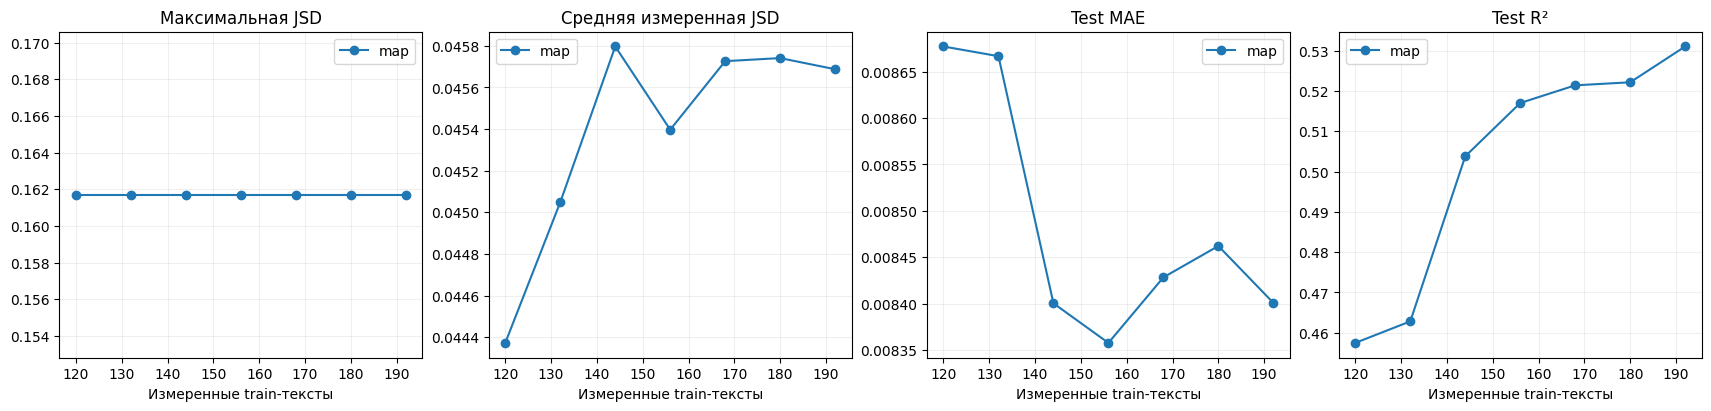

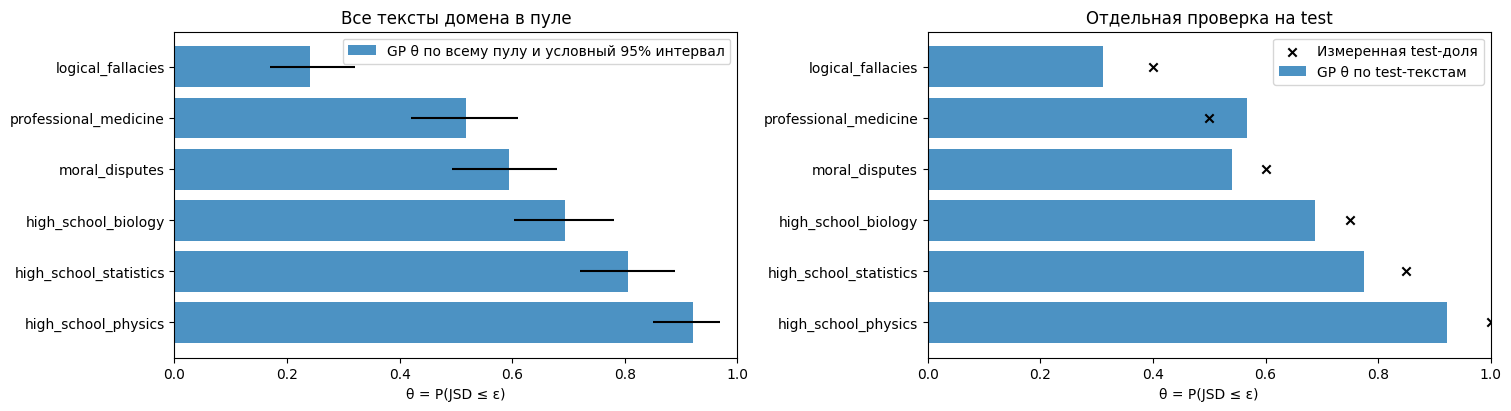

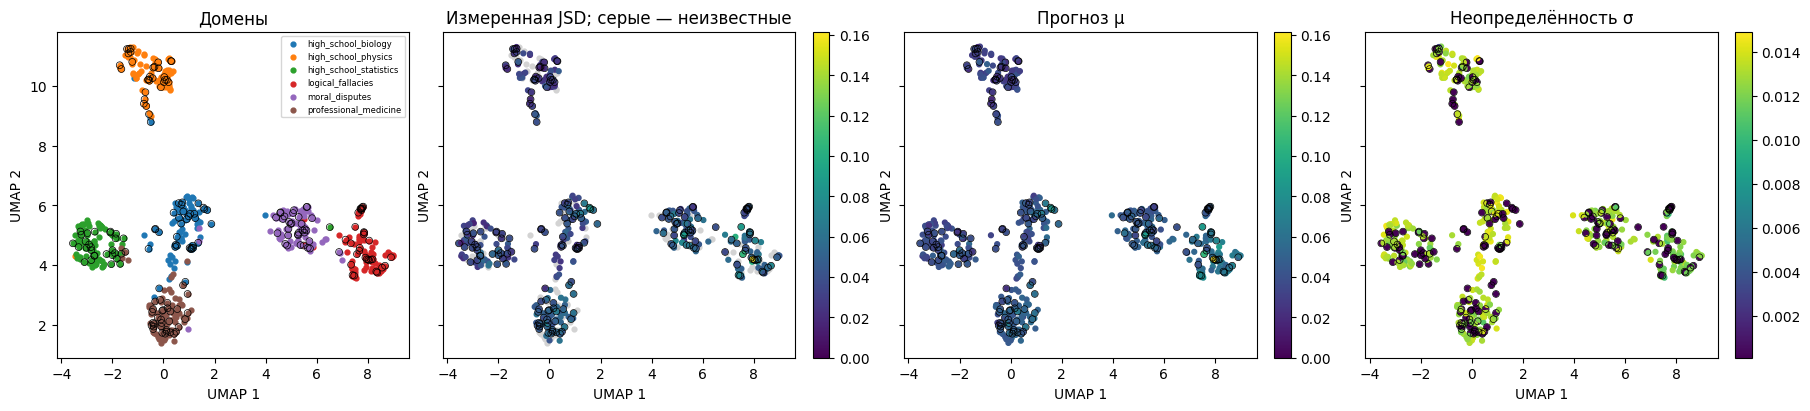

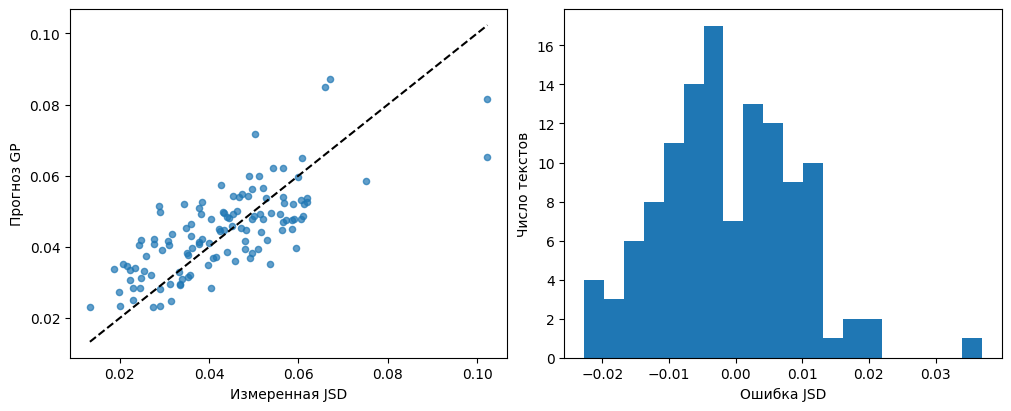

Графики: /content/qwen_gp_demo_20261007/live_runs/32f95d0b9b86ced4/plots


In [18]:
# QWEN_CELL: plots
plot_directory=show_task(task)
print("Графики:",plot_directory)


## Результаты

Сохраняем конфиг, тексты, split, признаки, измерения, состояния GP, карту, FE, графики и выполненный код.


In [19]:
# QWEN_CELL: archive
save_json(task.output+'/notebook_runtime.json',dict(version=NOTEBOOK_VERSION,query_scope=MAP_QUERY_SCOPE,
    seconds=time.perf_counter()-STARTED,public_map=PUBLIC_MAP,
    domain_query_counts=result['domain_map_query_counts'],split_counts={p:len(ids) for p,ids in task.split.items()},
    public_map_unchanged_after_evaluation=True,transformers=transformers.__version__,torch=torch.__version__))
map_table.to_csv(runtime.ROOT/task.output/'notebook_pool_map.csv',index=False)
archive_path=Path(task.package(config['archive_path']))
history=get_ipython().history_manager.input_hist_raw
cell_sources={}
for entry in history:
    if entry.startswith('# QWEN_CELL: '):
        tag=entry.splitlines()[0].split(': ',1)[1]
        cell_sources[tag]=entry
with zipfile.ZipFile(archive_path) as z:
    contents={n:z.read(n) for n in z.namelist() if not n.endswith('/')}
contents['executed_notebook_cells.json']=json.dumps(cell_sources,ensure_ascii=False,indent=2).encode()
manifest={n:hashlib.sha256(value).hexdigest() for n,value in contents.items()}
with zipfile.ZipFile(archive_path,'w',zipfile.ZIP_DEFLATED) as z:
    for n,value in contents.items():z.writestr(n,value)
    z.writestr('RESULT_MANIFEST.json',json.dumps(manifest,ensure_ascii=False,indent=2))
print('Архив:',archive_path,'| MiB:',round(archive_path.stat().st_size/2**20,2))
from google.colab import files
files.download(str(archive_path))


Архив: /content/qwen_gp_demo_results.zip | MiB: 3.99


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>